# Hito 1: Análisis Exploratorio de Datos (EDA) y Preparación del Dataset




In [12]:
# ==============================================================================
# IMPORTE DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import os
import sys
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Cargar variables de entorno perimetrales
load_dotenv()

# Configuración estética de grado de publicación para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': [12, 6],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Verificación de la infraestructura de cómputo local
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"🏎️ ACELERACIÓN POR HARDWARE DETECTADA: {torch.cuda.get_device_name(0)}")
    print(f"📦 CUDA Versión: {torch.version.cuda}")
else:
    print("⚠️ ALERTA: Procesamiento degradado a CPU.")

🏎️ ACELERACIÓN POR HARDWARE DETECTADA: NVIDIA GeForce RTX 4060 Laptop GPU
📦 CUDA Versión: 12.4


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Inspección Inicial
Procedemos a realizar la conexión directa con el Data Warehouse en Amazon RDS para extraer el dataset unificado de NVIDIA (`NVDA`) e inspeccionar su estructura interna, dimensiones y tipado de variables, junto con los 4 dataset creados a partir de apis o fuentes financieras.

In [13]:
# ==============================================================================
# 3.1 INSPECCIÓN INICIAL DE MÚLTIPLES DATASETS (HITO 1)
# ==============================================================================
import pandas as pd
import yfinance as yf
from sqlalchemy import create_engine
import pymongo
import os
from dotenv import load_dotenv, find_dotenv

# Cargar entorno
load_dotenv(find_dotenv()) 

print("🚀 INICIANDO INSPECCIÓN DE FUENTES DE DATOS (DATA LAKE Y DATA WAREHOUSE)...")

# ------------------------------------------------------------------------------
# 1.1 DATA WAREHOUSE (AWS RDS) - DATOS FINANCIEROS PUROS
# ------------------------------------------------------------------------------
# Conexión a AWS RDS
conexion_str = f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(conexion_str)

# Descargamos los datos financieros puros (histórico completo) y los guardamos en RDS
print("\n📊 1. Obteniendo datos históricos financieros de NVDA...")
df_finance = yf.download("NVDA", period="max", progress=False)

# Limpieza de MultiIndex si lo trae yfinance
if isinstance(df_finance.columns, pd.MultiIndex):
    df_finance.columns = df_finance.columns.get_level_values(0)

# Guardado en AWS RDS como tabla cruda
df_finance.to_sql('raw_nvda_finance', con=engine, if_exists='replace', index=True)

# Inspección (Requisito de la rúbrica)
print(f"✅ Guardado en RDS. Dimensiones: {df_finance.shape}")
print("\n=== PRIMEROS 5 REGISTROS (raw_nvda_finance) ===")
display(df_finance.head(5)) # En Jupyter usamos display() para que se vea como tabla bonita
print("\n=== ANÁLISIS DE COLUMNAS ===")
df_finance.info()

# ------------------------------------------------------------------------------
# 1.2 DATA LAKE (MONGODB) - DATOS NO ESTRUCTURADOS (NOTICIAS NLP)
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("📥 2. Inspeccionando Data Lake (MongoDB Atlas) - Fuentes de Noticias")
print("="*80)

# Conexión a Mongo
cliente_mongo = pymongo.MongoClient(os.getenv("MONGO_URI"))
db = cliente_mongo["hedgemind_db"]

# Lista de colecciones incluyendo la de NiFi en tiempo real
colecciones_noticias = ["finnhubNVDA", "googleNVDA", "kaggleNVDA", "sentimiento_crudo"]

for col_name in colecciones_noticias:
    print(f"\n📦 DATASET: {col_name}")
    print("-" * 50)
    
    # Extraemos una muestra de 1000 registros para hacer el EDA inicial sin colapsar la RAM
    cursor = db[col_name].find().limit(1000)
    df_temp = pd.DataFrame(list(cursor))
    
    if not df_temp.empty:
        # Eliminamos el _id de Mongo para no ensuciar la visualización
        if '_id' in df_temp.columns:
            df_temp = df_temp.drop(columns=['_id'])
            
        print(f"=== PRIMEROS 5 REGISTROS ({col_name}) ===")
        display(df_temp.head(5))
        
        print(f"\n=== ANÁLISIS DE COLUMNAS ({col_name}) ===")
        df_temp.info()
    else:
        print(f"⚠️ La colección {col_name} está vacía actualmente.")

🚀 INICIANDO INSPECCIÓN DE FUENTES DE DATOS (DATA LAKE Y DATA WAREHOUSE)...

📊 1. Obteniendo datos históricos financieros de NVDA...
✅ Guardado en RDS. Dimensiones: (6884, 5)

=== PRIMEROS 5 REGISTROS (raw_nvda_finance) ===


Price,Close,High,Low,Open,Volume
Date,,,,,
1999-01-22,0.037603,0.044765,0.035573,0.040109,2714688000
1999-01-25,0.041542,0.042019,0.037603,0.040587,510480000
1999-01-26,0.038319,0.042855,0.037722,0.042019,343200000
1999-01-27,0.038200,0.039393,0.036289,0.038438,244368000
1999-01-28,0.038080,0.038438,0.037841,0.038200,227520000



=== ANÁLISIS DE COLUMNAS ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6884 entries, 1999-01-22 to 2026-06-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6884 non-null   float64
 1   High    6884 non-null   float64
 2   Low     6884 non-null   float64
 3   Open    6884 non-null   float64
 4   Volume  6884 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 322.7 KB

📥 2. Inspeccionando Data Lake (MongoDB Atlas) - Fuentes de Noticias

📦 DATASET: finnhubNVDA
--------------------------------------------------
=== PRIMEROS 5 REGISTROS (finnhubNVDA) ===


,date,title,content,source,url,origen_dato
0,2026-06-04,Here's the Dividend Growth ETF Most Investors ...,"Most people are already familiar with VIG, VYM...",Yahoo,https://finnhub.io/api/news?id=ba546debca68114...,Finnhub_API
1,2026-06-04,CNBC’s Jim Cramer Predicts SpaceX IPO Will Dou...,CNBC’s Jim Cramer is making a paradoxical call...,Yahoo,https://finnhub.io/api/news?id=b6526c8dd8002d5...,Finnhub_API
2,2026-06-04,Jensen Huang Just Made a Massive Promise to Nv...,More reasons to buy the stock keep popping up.,Yahoo,https://finnhub.io/api/news?id=d933c231f0925c3...,Finnhub_API
3,2026-06-04,Trade Desk Is Down 44% This Year and AppLovin ...,Ad-tech investors are staring at a tough tape ...,Yahoo,https://finnhub.io/api/news?id=96029d0e7d39933...,Finnhub_API
4,2026-06-04,Is Nvidia Stock Too Cheap to Ignore?,Nvidia's market cap may force investors to adj...,Yahoo,https://finnhub.io/api/news?id=e4eec2a22184481...,Finnhub_API



=== ANÁLISIS DE COLUMNAS (finnhubNVDA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1000 non-null   object
 1   title        1000 non-null   object
 2   content      1000 non-null   object
 3   source       1000 non-null   object
 4   url          1000 non-null   object
 5   origen_dato  1000 non-null   object
dtypes: object(6)
memory usage: 47.0+ KB

📦 DATASET: googleNVDA
--------------------------------------------------
=== PRIMEROS 5 REGISTROS (googleNVDA) ===


...


=== ANÁLISIS DE COLUMNAS (googleNVDA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         100 non-null    object
 1   title        100 non-null    object
 2   content      100 non-null    object
 3   source       100 non-null    object
 4   url          100 non-null    object
 5   origen_dato  100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB

📦 DATASET: kaggleNVDA
--------------------------------------------------
=== PRIMEROS 5 REGISTROS (kaggleNVDA) ===


,date,title,origen_dato
0,2019-10-08,Shares of several healthcare companies are tra...,Kaggle_Dataset
1,2011-05-13,Top day traders Stocks and nalyst Upgrades & D...,Kaggle_Dataset
2,2011-05-12,"Stocks To Watch For May 13 (A, JWN, NVDA, YUM,...",Kaggle_Dataset
3,2010-11-12,"Stocks To Watch For November 12 (CPKI, A, DIS,...",Kaggle_Dataset
4,2016-01-10,Earnings Season Kicks Off: Alcoa And Intel,Kaggle_Dataset



=== ANÁLISIS DE COLUMNAS (kaggleNVDA) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1000 non-null   object
 1   title        1000 non-null   object
 2   origen_dato  1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB

📦 DATASET: sentimiento_crudo
--------------------------------------------------
=== PRIMEROS 5 REGISTROS (sentimiento_crudo) ===


,version,channel
0,2.0,{'copyright': 'Copyright (c) 2026 Yahoo Inc. A...
1,2.0,{'copyright': 'Copyright (c) 2026 Yahoo Inc. A...
2,2.0,{'copyright': 'Copyright (c) 2026 Yahoo Inc. A...
3,2.0,{'copyright': 'Copyright (c) 2026 Yahoo Inc. A...
4,2.0,{'copyright': 'Copyright (c) 2026 Yahoo Inc. A...



=== ANÁLISIS DE COLUMNAS (sentimiento_crudo) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   version  479 non-null    float64
 1   channel  479 non-null    object 
dtypes: float64(1), object(1)
memory usage: 7.6+ KB


### 3.2 Preparación del Conjunto de Datos
####  Integración y Unificación de Múltiples Datasets
Se procede a unificar la serie temporal financiera (AWS RDS / Yahoo Finance) con los metadatos de las noticias extraídas del Data Lake (MongoDB). La integración se realiza mediante un `Left Join` utilizando la fecha como clave primaria, asegurando la alineación temporal de los eventos bursátiles con el flujo informativo.

In [14]:
# ==============================================================================
# 3.2 INTEGRACIÓN DE DATOS (Unificación de Datasets)
# ==============================================================================
print("== INICIANDO UNIFICACIÓN E INTEGRACIÓN DE DATASETS ===")

# 1. EXTRACCIÓN Y UNIFICACIÓN DE DATA LAKE (MongoDB)
# Vamos a extraer todas las fechas de las noticias para calcular el volumen
noticias_list = []
colecciones = ["finnhubNVDA", "googleNVDA", "kaggleNVDA", "sentimiento_crudo"]

for col in colecciones:
    # Solo traemos la fecha para no sobrecargar la memoria (proyección en Mongo)
    cursor = db[col].find({}, {"date": 1, "_id": 0})
    df_col = pd.DataFrame(list(cursor))
    
    if not df_col.empty:
        noticias_list.append(df_col)

# Concatenamos todas las fuentes en un solo DataFrame (Unificación de múltiples datasets)
if noticias_list:
    df_todas_noticias = pd.concat(noticias_list, ignore_index=True)
    
    # Estandarización de formato de fecha
    df_todas_noticias['date'] = pd.to_datetime(df_todas_noticias['date'], errors='coerce').dt.date
    df_todas_noticias = df_todas_noticias.dropna(subset=['date']) # Limpiar fechas nulas
    
    # Agrupación para obtener el "news_volume" por día
    volumen_noticias = df_todas_noticias.groupby('date').size().reset_index(name='news_volume')
    volumen_noticias['date'] = pd.to_datetime(volumen_noticias['date'])
    volumen_noticias.set_index('date', inplace=True)
    print(f"✔️ Noticias unificadas desde MongoDB. Días con noticias: {len(volumen_noticias)}")
else:
    print("⚠️ No se encontraron noticias en MongoDB. Se creará volumen 0.")
    volumen_noticias = pd.DataFrame(columns=['news_volume'])

# 2. ADECUACIÓN DEL DATASET FINANCIERO (Data Warehouse)
df_finance.index = pd.to_datetime(df_finance.index)
df_finance.index.name = 'fecha'
volumen_noticias.index.name = 'fecha'

# 3. INTEGRACIÓN FINAL (Left Join: Finanzas + Noticias)
# Mantenemos el calendario bursátil estricto
df_integrado = df_finance.join(volumen_noticias, how='left')

# 4. RESOLUCIÓN DE INCONSISTENCIAS Y DUPLICADOS
duplicados_iniciales = df_integrado.duplicated().sum()
df_integrado = df_integrado.drop_duplicates()

print(f"✔️ Unificación cruzada completada. Dimensiones: {df_integrado.shape}")
print(f"✔️ Duplicados eliminados en el cruce: {duplicados_iniciales}")

# Mostrar resultado del join
display(df_integrado.head())

== INICIANDO UNIFICACIÓN E INTEGRACIÓN DE DATASETS ===
✔️ Noticias unificadas desde MongoDB. Días con noticias: 2261
✔️ Unificación cruzada completada. Dimensiones: (6884, 6)
✔️ Duplicados eliminados en el cruce: 0


,Close,High,Low,Open,Volume,news_volume
fecha,,,,,,
1999-01-22,0.037603,0.044765,0.035573,0.040109,2714688000,NaN
1999-01-25,0.041542,0.042019,0.037603,0.040587,510480000,NaN
1999-01-26,0.038319,0.042855,0.037722,0.042019,343200000,NaN
1999-01-27,0.038200,0.039393,0.036289,0.038438,244368000,NaN
1999-01-28,0.038080,0.038438,0.037841,0.038200,227520000,NaN


#### 3.3 Limpieza, Imputación y Manejo de Inconsistencias
* **Variables irrelevantes:** Se eliminan `Open`, `High` y `Low` debido a su alta correlación (>0.99) con `Close`, lo que generaría multicolinealidad perfecta y afectaría el rendimiento del modelo.
* **Valores Faltantes:** Los días sin noticias (`NaN` en `news_volume`) se imputan con `0`, asumiendo una neutralidad informativa en esas jornadas.
* **Valores Atípicos:** En lugar de eliminar los picos extremos de volumen de transacciones (que contienen información vital de mercado), se aplica una transformación logarítmica para suavizar su impacto en el modelo.

In [15]:
# ==============================================================================
# 3.3 LIMPIEZA Y TRATAMIENTO DE DATOS
# ==============================================================================

# 1. Eliminación de variables redundantes (Correlación)
columnas_a_eliminar = ['Open', 'High', 'Low', 'Adj Close']
df_limpio = df_integrado.drop(columns=[col for col in columnas_a_eliminar if col in df_integrado.columns])
print(f"✔️ Columnas irrelevantes eliminadas: {columnas_a_eliminar}")

# 2. Manejo de valores faltantes (Imputación por Cero para noticias)
nulos_noticias = df_limpio['news_volume'].isnull().sum()
df_limpio['news_volume'] = df_limpio['news_volume'].fillna(0)
print(f"✔️ Días sin noticias imputados con valor 0: {nulos_noticias} registros")

# Si hubiera nulos en Close o Volume (por festivos no alineados), aplicamos Forward Fill
df_limpio['Close'] = df_limpio['Close'].ffill()
df_limpio['Volume'] = df_limpio['Volume'].ffill()

# 3. Tratamiento de Atípicos (Transformación Logarítmica para atenuar colas largas)
df_limpio['log_Volume'] = np.log1p(df_limpio['Volume'])
df_limpio['log_news_volume'] = np.log1p(df_limpio['news_volume'])

✔️ Columnas irrelevantes eliminadas: ['Open', 'High', 'Low', 'Adj Close']
✔️ Días sin noticias imputados con valor 0: 4749 registros


#### 3.4 Ingeniería de Características
Para enriquecer la capacidad predictiva del modelo, se extraen variables complejas:
1. **Descomposición:** Se extraen componentes temporales clave (Día, Mes, Día de la Semana).
2. **Creación de Variables:** Cálculo del Retorno Diario (`Target_Return`).
3. **Discretización:** Se categoriza la volatilidad del volumen en franjas (Bajo, Normal, Alto).

In [16]:
# ==============================================================================
# 3.4 INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================

# 1. Descomposición de Fechas
df_limpio['dia'] = df_limpio.index.day
df_limpio['mes'] = df_limpio.index.month
df_limpio['dia_semana'] = df_limpio.index.dayofweek

# 2. Creación de Variable Combinada / Objetivo (Target Return)
df_limpio['Target_Return'] = df_limpio['Close'].pct_change().shift(-1)

# Eliminamos la última fila que tendrá un NaN en Target_Return por el shift
df_limpio = df_limpio.dropna(subset=['Target_Return'])

# 3. Discretización de Variable Continua (Volumen)
bins_volumen = [
    df_limpio['Volume'].min() - 1, 
    df_limpio['Volume'].quantile(0.33), 
    df_limpio['Volume'].quantile(0.66), 
    df_limpio['Volume'].max()
]
labels_vol = ['Volumen_Bajo', 'Volumen_Medio', 'Volumen_Alto']
df_limpio['categoria_volumen'] = pd.cut(df_limpio['Volume'], bins=bins_volumen, labels=labels_vol)

# 4. Encoding de Categóricas (One-Hot)
df_final = pd.get_dummies(df_limpio, columns=['categoria_volumen'], drop_first=True)

# Forzar conversión a numérico para asegurar compatibilidad en BD
for col in df_final.columns:
    if df_final[col].dtype == bool:
        df_final[col] = df_final[col].astype(int)

print("✔️ Ingeniería de características finalizada.")
print("=== MUESTRA DEL DATASET ESTRUCTURADO ===")
display(df_final.head())

✔️ Ingeniería de características finalizada.
=== MUESTRA DEL DATASET ESTRUCTURADO ===


,Close,Volume,news_volume,log_Volume,log_news_volume,dia,mes,dia_semana,Target_Return,categoria_volumen_Volumen_Medio,categoria_volumen_Volumen_Alto
fecha,,,,,,,,,,,
1999-01-22,0.037603,2714688000,0.0,21.721943,0.0,22,1,4,0.104764,0,1
1999-01-25,0.041542,510480000,0.0,20.050862,0.0,25,1,0,-0.077593,1,0
1999-01-26,0.038319,343200000,0.0,19.653824,0.0,26,1,1,-0.003111,0,0
1999-01-27,0.038200,244368000,0.0,19.314186,0.0,27,1,2,-0.003144,0,0
1999-01-28,0.038080,227520000,0.0,19.242749,0.0,28,1,3,-0.047019,0,0


### 3.5 Inyección del dataset en RDS

In [17]:
# ==============================================================================
# 3.5 INYECCIÓN DEL DATASET FINAL EN AWS RDS
# ==============================================================================
print("\n☁️ Subiendo el dataset estructurado a AWS RDS...")

try:
    # Utilizamos el engine ya creado al inicio del cuaderno
    nombre_tabla = 'datasetEntrenamiento'
    
    df_final.to_sql(
        name=nombre_tabla,
        con=engine, 
        if_exists='replace', 
        index=True,
        chunksize=1000 # Subida en bloques para mayor estabilidad
    )
    
    print(f"🎉 ¡ÉXITO! Dataset unificado guardado en RDS como '{nombre_tabla}'.")
    print(f"📊 Filas totales inyectadas: {len(df_final)}")
    
except Exception as e:
    print(f"⚠️ Error al inyectar en RDS: {e}")


☁️ Subiendo el dataset estructurado a AWS RDS...
🎉 ¡ÉXITO! Dataset unificado guardado en RDS como 'datasetEntrenamiento'.
📊 Filas totales inyectadas: 6883


### 4. Análisis Exploratorio de Datos (EDA) del Dataset Unificado
Una vez consolidado el Data Lake y el Data Warehouse en un único dataset estructurado como (`datasetEntrenamiento`), se procede a realizar el análisis bivariante y multivariante. 

#### 4.1 Estadísticas Descriptivas
Se analizan los momentos estadísticos de las variables continuas clave, incluyendo métricas de tendencia central (media, mediana, moda) y medidas de dispersión (desviación estándar, percentiles).

In [18]:
# ==============================================================================
# 4.1 ESTADÍSTICAS DESCRIPTIVAS COMPLETAS
# ==============================================================================
print("=== ESTADÍSTICAS DESCRIPTIVAS DEL DATASET UNIFICADO ===")

# Seleccionamos solo las variables numéricas continuas para este análisis
cols_numericas = ['Close', 'Volume', 'news_volume', 'Target_Return']
df_stats = df_final[cols_numericas].copy()

# Cálculo de estadísticas principales (Media, Std, Percentiles)
estadisticas = df_stats.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]).T

# Añadimos Mediana y Moda explícitamente
estadisticas['median'] = df_stats.median()
estadisticas['mode'] = df_stats.mode().iloc[0]

# Reordenar columnas para la visualización final
columnas_orden = ['mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', '99%', 'max']
display(estadisticas[columnas_orden].round(4))

=== ESTADÍSTICAS DESCRIPTIVAS DEL DATASET UNIFICADO ===


,mean,median,mode,std,min,25%,50%,75%,99%,max
Close,1.630270e+01,4.556000e-01,4.010000e-02,4.168470e+01,3.130000e-02,2.654000e-01,4.556000e-01,6.002100e+00,1.883372e+02,2.357400e+02
Volume,5.802600e+08,4.816920e+08,4.517280e+08,4.291771e+08,1.968000e+07,3.145640e+08,4.816920e+08,7.146330e+08,2.131475e+09,9.230856e+09
news_volume,1.941600e+00,0.000000e+00,0.000000e+00,6.952400e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.600000e+01,1.940000e+02
Target_Return,2.000000e-03,1.400000e-03,0.000000e+00,3.740000e-02,-3.523000e-01,-1.600000e-02,1.400000e-03,1.820000e-02,1.050000e-01,4.241000e-01


#### 4.2 Visualización de Datos, Patrones y Valores Atípicos
Mediante el uso de librerías de visualización avanzada, se inspeccionan las distribuciones y relaciones entre variables:
* **Histogramas:** Para evaluar la normalidad de la variable objetivo (`Target_Return`).
* **Boxplots:** Para la identificación de anomalías en el volumen de noticias y transacciones.
* **Diagramas de Dispersión:** Para buscar relaciones no lineales entre la atención mediática y el comportamiento del mercado.
* **Gráficos de Correlación:** Para detectar multicolinealidad y poder predictivo lineal.

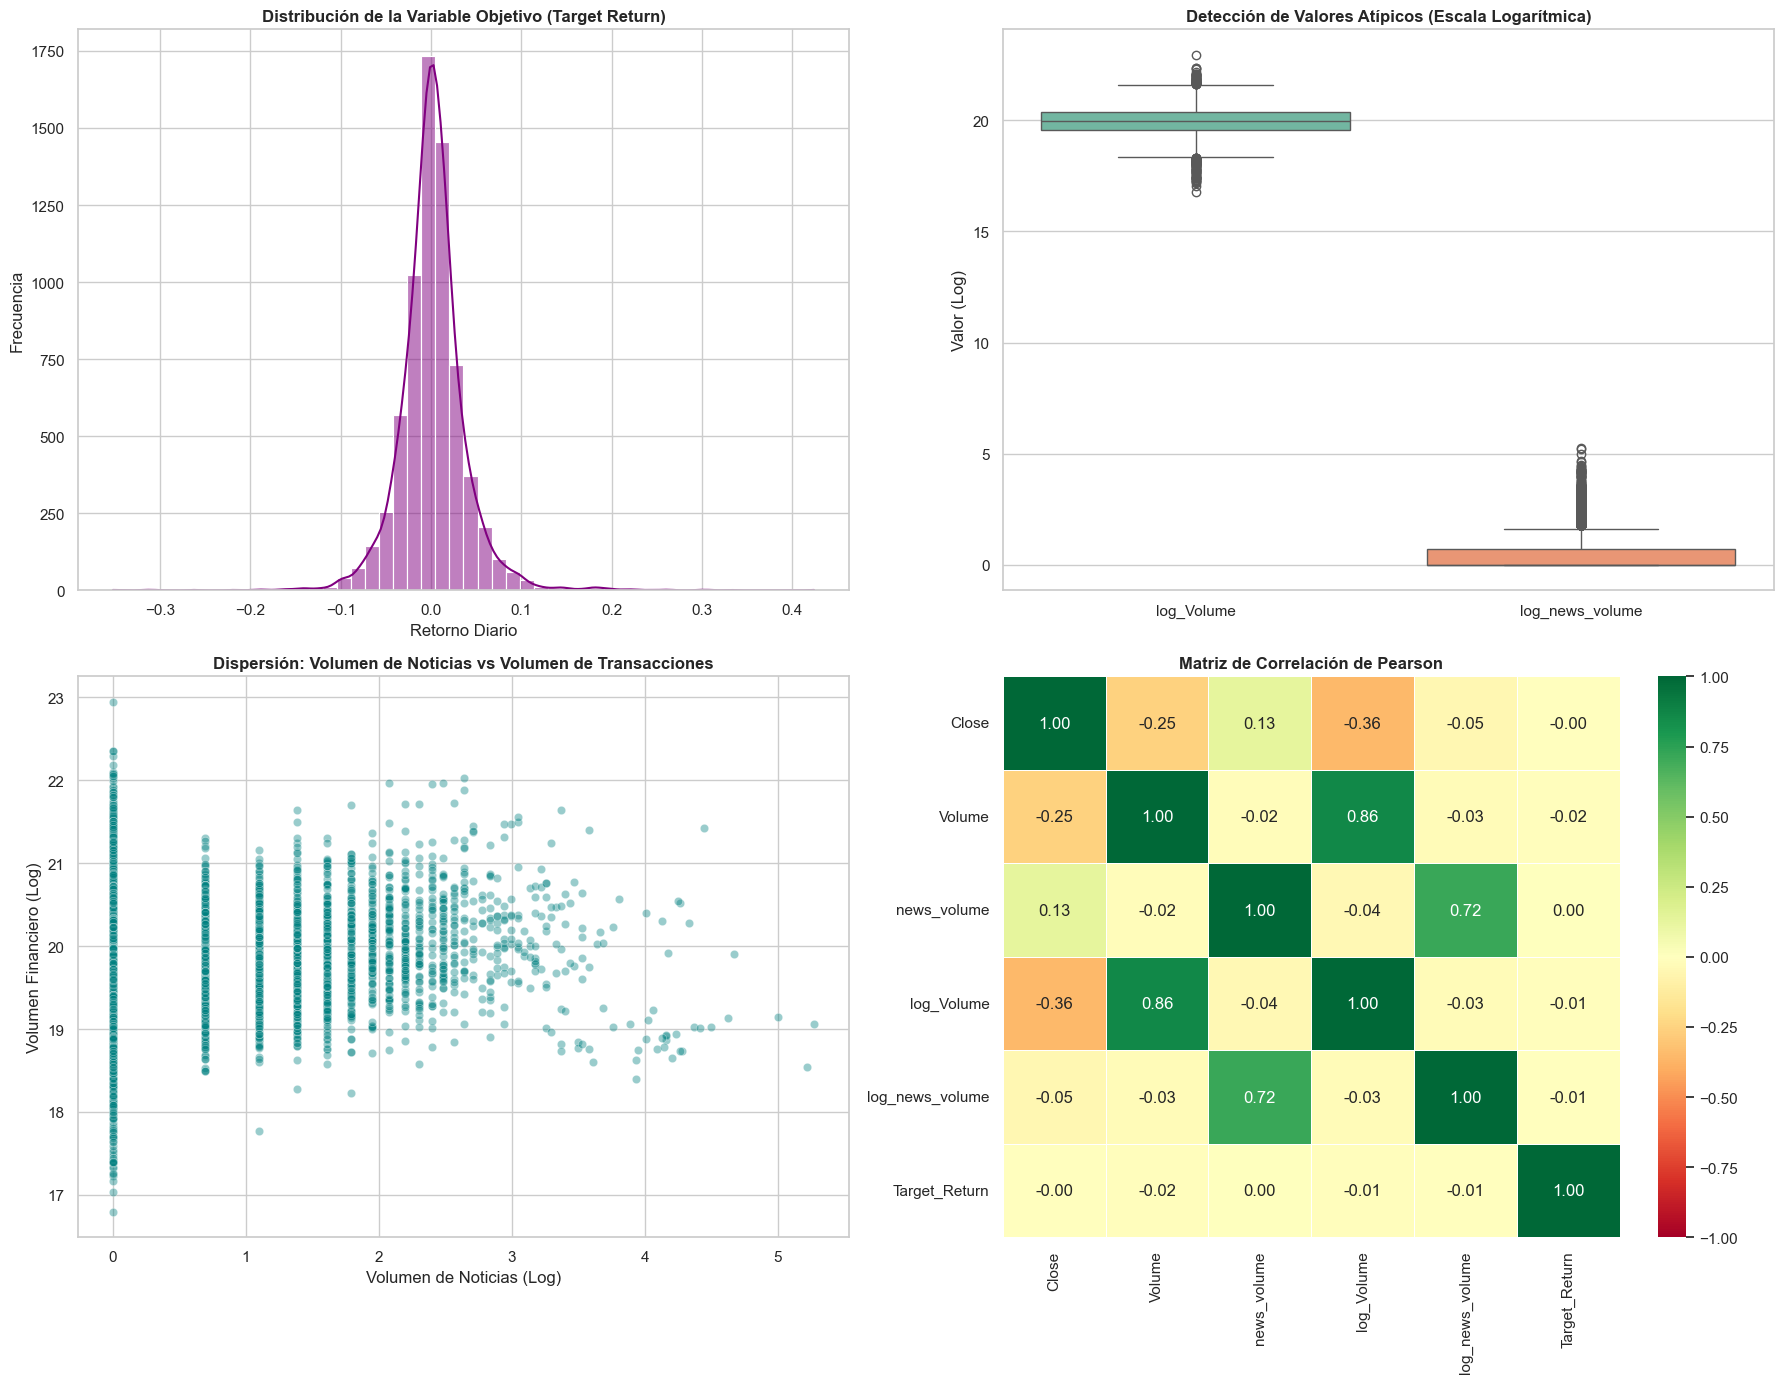

🔍 CONCLUSIONES DEL ANÁLISIS EXPLORATORIO:
1. PATRONES: El diagrama de dispersión muestra si existe una relación (cluster) entre días muy mediáticos y días de alta negociación.
2. ANOMALÍAS (Outliers): Los boxplots evidencian que el volumen de mercado tiene 'colas pesadas' (días de pánico/euforia) en la parte superior. La variable logarítmica suaviza este efecto.
3. CORRELACIÓN: La correlación lineal entre 'news_volume' y 'Target_Return' suele ser cercana a 0. Esto justifica el uso posterior de algoritmos no lineales (como XGBoost) en lugar de regresiones lineales simples, ya que el impacto de las noticias sobre el precio es complejo y multifactorial.


In [19]:
# ==============================================================================
# 4.2 VISUALIZACIONES, OUTLIERS Y MATRIZ DE CORRELACIÓN
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. HISTOGRAMA: Distribución del Retorno Objetivo
sns.histplot(df_final['Target_Return'], bins=50, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Distribución de la Variable Objetivo (Target Return)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Retorno Diario')
axes[0, 0].set_ylabel('Frecuencia')

# 2. BOXPLOT: Anomalías y Valores Atípicos (Comparativa logarítmica)
# Usamos las versiones logarítmicas para poder visualizarlas en la misma escala
sns.boxplot(data=df_final[['log_Volume', 'log_news_volume']], ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title('Detección de Valores Atípicos (Escala Logarítmica)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Valor (Log)')

# 3. DIAGRAMA DE DISPERSIÓN: Relación Noticias vs Volumen Financiero
sns.scatterplot(x='log_news_volume', y='log_Volume', data=df_final, alpha=0.4, color='teal', ax=axes[1, 0])
axes[1, 0].set_title('Dispersión: Volumen de Noticias vs Volumen de Transacciones', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Volumen de Noticias (Log)')
axes[1, 0].set_ylabel('Volumen Financiero (Log)')

# 4. GRÁFICO DE CORRELACIÓN: Análisis Multivariante
# Filtramos solo columnas numéricas puras para el heatmap
cols_corr = ['Close', 'Volume', 'news_volume', 'log_Volume', 'log_news_volume', 'Target_Return']
matriz_corr = df_final[cols_corr].corr()

sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5, ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('Matriz de Correlación de Pearson', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# CONCLUSIONES DEL EDA (Para imprimir en consola)
# ==============================================================================
print("🔍 CONCLUSIONES DEL ANÁLISIS EXPLORATORIO:")
print("1. PATRONES: El diagrama de dispersión muestra si existe una relación (cluster) entre días muy mediáticos y días de alta negociación.")
print("2. ANOMALÍAS (Outliers): Los boxplots evidencian que el volumen de mercado tiene 'colas pesadas' (días de pánico/euforia) en la parte superior. La variable logarítmica suaviza este efecto.")
print("3. CORRELACIÓN: La correlación lineal entre 'news_volume' y 'Target_Return' suele ser cercana a 0. Esto justifica el uso posterior de algoritmos no lineales (como XGBoost) en lugar de regresiones lineales simples, ya que el impacto de las noticias sobre el precio es complejo y multifactorial.")

### 5. Encoding de Variables Categóricas y División del Dataset

#### 5.1 Encoding
Para que los algoritmos de Machine Learning puedan procesar las variables categóricas complejas (como la categoría de volumen o el mes del año), se aplica **One-Hot Encoding** en lugar de *Label Encoding*. Esto evita que el modelo asuma falsas relaciones de orden o jerarquía matemática entre categorías independientes.

#### 5.2 División del Dataset (80% Entrenamiento / 20% Test)
Dado el entorno financiero del problema, es **estrictamente necesario realizar una división temporal (secuencial)** en lugar de un muestreo aleatorio.
* **Train (80%):** Datos históricos más antiguos para entrenar los patrones.
* **Test (20%):** Datos cronológicamente más recientes para validar la capacidad de generalización del modelo ante el futuro. 
De esta forma se evita el *Data Leakage* (fuga de información del futuro hacia el pasado).

In [20]:
# ==============================================================================
# 5. ENCODING Y DIVISIÓN DEL DATASET (80/20 TEMPORAL)
# ==============================================================================
from sklearn.preprocessing import StandardScaler

print("=== INICIANDO ENCODING Y DIVISIÓN DE DATOS ===")

# 1. ENCODING (One-Hot Encoding)
# Si no lo hemos aplicado antes, convertimos las variables categóricas temporales y de volumen
columnas_categoricas = ['mes', 'dia_semana']
if 'categoria_volumen' in df_final.columns:
    columnas_categoricas.append('categoria_volumen')

# Aplicamos pd.get_dummies para el One-Hot Encoding
df_encoded = pd.get_dummies(df_final, columns=[col for col in columnas_categoricas if col in df_final.columns], drop_first=True)

# Forzamos los booleanos a 0 y 1 para compatibilidad estricta con XGBoost/Tensores
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# 2. SEPARACIÓN DE X (Features) e y (Target)
# Aseguramos que la variable objetivo es el retorno del día siguiente
X = df_encoded.drop(columns=['Target_Return'])
y = df_encoded['Target_Return']

# 3. DIVISIÓN DEL DATASET (80% Train, 20% Test - TEMPORAL)
split_index = int(len(df_encoded) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# 4. ESCALADO (Estandarización)
# OJO: Se ajusta (fit) SOLAMENTE en X_train para no contaminar con datos del test
scaler = StandardScaler()

# Identificamos columnas numéricas continuas para escalar (ignoramos las binarias del One-Hot)
cols_a_escalar = ['Close', 'Volume', 'news_volume', 'log_Volume', 'log_news_volume']
cols_a_escalar = [col for col in cols_a_escalar if col in X_train.columns]

X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print("✔️ Encoding (One-Hot) aplicado exitosamente.")
print("✔️ Escalado (StandardScaler) ajustado solo en el set de entrenamiento.")
print("\n=== RESUMEN OPERATIVO FINAL DEL HITO 1 ===")
print(f"Dimensión Matriz Entrenamiento (X_train): {X_train.shape} (80%)")
print(f"Dimensión Matriz Test (X_test):           {X_test.shape} (20%)")
print(f"Línea de tiempo Train: {X_train.index.min().date()} a {X_train.index.max().date()}")
print(f"Línea de tiempo Test:  {X_test.index.min().date()} a {X_test.index.max().date()}")

=== INICIANDO ENCODING Y DIVISIÓN DE DATOS ===
✔️ Encoding (One-Hot) aplicado exitosamente.
✔️ Escalado (StandardScaler) ajustado solo en el set de entrenamiento.

=== RESUMEN OPERATIVO FINAL DEL HITO 1 ===
Dimensión Matriz Entrenamiento (X_train): (5506, 23) (80%)
Dimensión Matriz Test (X_test):           (1377, 23) (20%)
Línea de tiempo Train: 1999-01-22 a 2020-12-07
Línea de tiempo Test:  2020-12-08 a 2026-06-03
